<a href="https://colab.research.google.com/github/JaredOzarzak/biomechanics-analysis-pipeline/blob/main/Baseball_VALD_Performance_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

# 1. List of 15 realistic fake names
fake_names = [
    'Jack Thompson', 'Marcus Reed', 'Sam Collins', 'Tyler Vance', 'Leo Martinez',
    'Derek Hayes', 'Jordan Bell', 'Caleb Ortiz', 'Grant Miller', 'Shane Walker',
    'Nate Robinson', 'Alex Foster', 'Blake Murphy', 'Justin Price', 'Evan Brooks'
]

positions = ['Pitcher', 'Catcher', 'Infield', 'Outfield', 'Pitcher',
             'Infield', 'Outfield', 'Pitcher', 'Catcher', 'Pitcher',
             'Infield', 'Outfield', 'Pitcher', 'Infield', 'Outfield']

# 2. Generate the VALD / EBP Performance Metrics
data = {
    'Player_Name': fake_names,
    'Position': positions,
    'Jump_Height_cm': np.random.uniform(32, 58, 15).round(2),
    'Peak_Power_Wkg': np.random.uniform(48, 68, 15).round(2),
    'RSI_mod': np.random.uniform(0.30, 0.65, 15).round(2),
    'Eccentric_Decel_Impulse': np.random.uniform(170, 260, 15).round(1),
    'NordBord_L_Torque': np.random.uniform(280, 480, 15).round(0),
    'NordBord_R_Torque': np.random.uniform(280, 480, 15).round(0),
    'Shoulder_ER_IR_Ratio': np.random.uniform(0.75, 1.15, 15).round(2)
}

# 3. Save as CSV
baseball_stats = pd.DataFrame(data)
baseball_stats.to_csv('team_performance_report.csv', index=False)

print("✅ SUCCESS: 'team_performance_report.csv' is ready in your sidebar.")
print(baseball_stats.head())

✅ SUCCESS: 'team_performance_report.csv' is ready in your sidebar.
     Player_Name  Position  Jump_Height_cm  Peak_Power_Wkg  RSI_mod  \
0  Jack Thompson   Pitcher           48.18           48.81     0.54   
1    Marcus Reed   Catcher           38.89           57.29     0.57   
2    Sam Collins   Infield           46.62           58.22     0.34   
3    Tyler Vance  Outfield           32.72           66.91     0.48   
4   Leo Martinez   Pitcher           53.66           66.80     0.61   

   Eccentric_Decel_Impulse  NordBord_L_Torque  NordBord_R_Torque  \
0                    194.2              398.0              363.0   
1                    207.1              290.0              476.0   
2                    238.3              459.0              330.0   
3                    224.4              443.0              335.0   
4                    183.3              298.0              403.0   

   Shoulder_ER_IR_Ratio  
0                  0.87  
1                  1.00  
2                  

In [3]:
# 1. Calculate the Hamstring Asymmetry (L vs R Torque)
# Formula: (Difference / Stronger Leg) * 100
baseball_stats['Asymmetry_Pct'] = (
    abs(baseball_stats['NordBord_L_Torque'] - baseball_stats['NordBord_R_Torque']) /
    baseball_stats[['NordBord_L_Torque', 'NordBord_R_Torque']].max(axis=1)
) * 100

# 2. Flag the "Danger Zone" (Anyone over 15% asymmetry)
red_flags = baseball_stats[baseball_stats['Asymmetry_Pct'] > 15]

print("--- 🚨 INJURY RISK REPORT: HAMSTRING ASYMMETRY (>15%) 🚨 ---")
if not red_flags.empty:
    print(red_flags[['Player_Name', 'Position', 'Asymmetry_Pct']].round(1))
else:
    print("All athletes within safe symmetry thresholds.")

# 3. Find the "Explosive Leaders" (Top RSI-mod)
top_movers = baseball_stats.nlargest(3, 'RSI_mod')
print("\n--- ⚡️ TOP EXPLOSIVE PERFORMERS (RSI-mod) ⚡️ ---")
print(top_movers[['Player_Name', 'Position', 'RSI_mod']])

--- 🚨 INJURY RISK REPORT: HAMSTRING ASYMMETRY (>15%) 🚨 ---
     Player_Name  Position  Asymmetry_Pct
1    Marcus Reed   Catcher           39.1
2    Sam Collins   Infield           28.1
3    Tyler Vance  Outfield           24.4
4   Leo Martinez   Pitcher           26.1
5    Derek Hayes   Infield           22.5
7    Caleb Ortiz   Pitcher           16.6
8   Grant Miller   Catcher           27.5
9   Shane Walker   Pitcher           15.4
13  Justin Price   Infield           16.7
14   Evan Brooks  Outfield           38.6

--- ⚡️ TOP EXPLOSIVE PERFORMERS (RSI-mod) ⚡️ ---
     Player_Name Position  RSI_mod
4   Leo Martinez  Pitcher     0.61
1    Marcus Reed  Catcher     0.57
0  Jack Thompson  Pitcher     0.54


/tmp/ipykernel_3977/1207030095.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=baseball_stats, x='Player_Name', y='Asymmetry_Pct', palette='Reds_d')


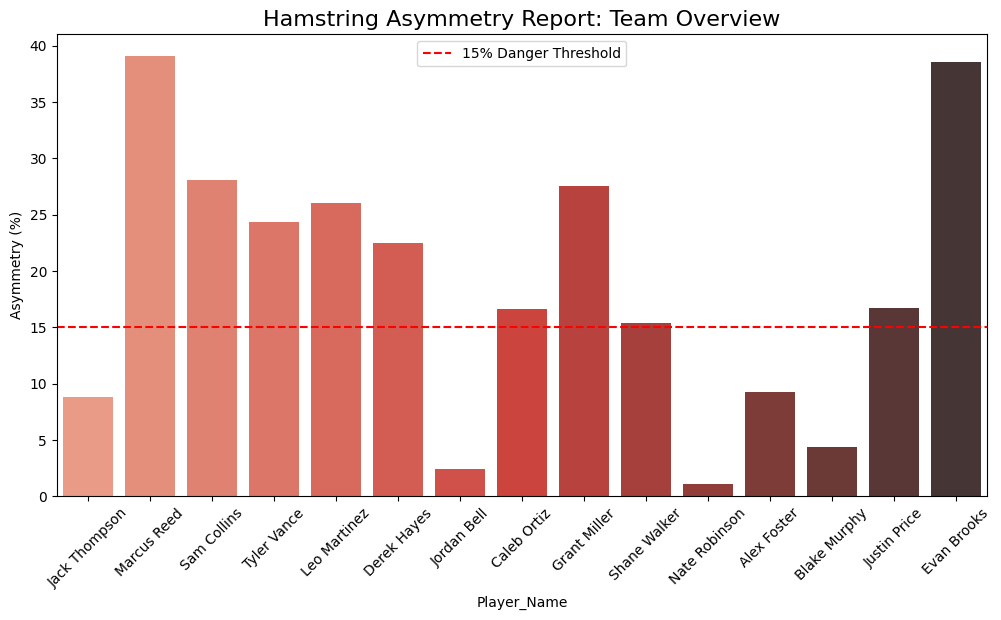

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
# Create the bar chart
sns.barplot(data=baseball_stats, x='Player_Name', y='Asymmetry_Pct', palette='Reds_d')

# Add the "EBP Threshold" line
plt.axhline(15, color='red', linestyle='--', label='15% Danger Threshold')

plt.title('Hamstring Asymmetry Report: Team Overview', fontsize=16)
plt.xticks(rotation=45)
plt.ylabel('Asymmetry (%)')
plt.legend()
plt.show()

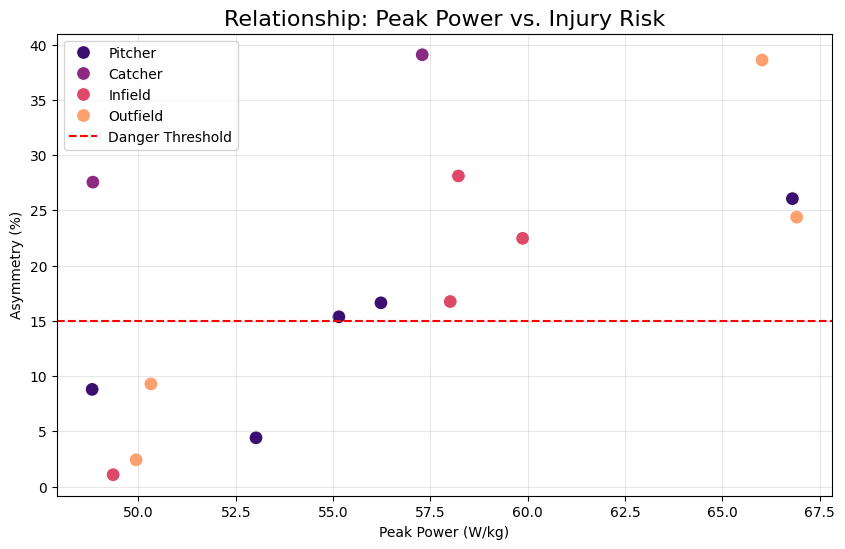

In [5]:
plt.figure(figsize=(10, 6))
# Create a scatter plot
sns.scatterplot(data=baseball_stats, x='Peak_Power_Wkg', y='Asymmetry_Pct',
                hue='Position', s=100, palette='magma')

# Add the 15% threshold line for context
plt.axhline(15, color='red', linestyle='--', label='Danger Threshold')

plt.title('Relationship: Peak Power vs. Injury Risk', fontsize=16)
plt.xlabel('Peak Power (W/kg)')
plt.ylabel('Asymmetry (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

/tmp/ipykernel_3977/2541978298.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=baseball_stats, x='Position', y='Asymmetry_Pct', palette='Set2')


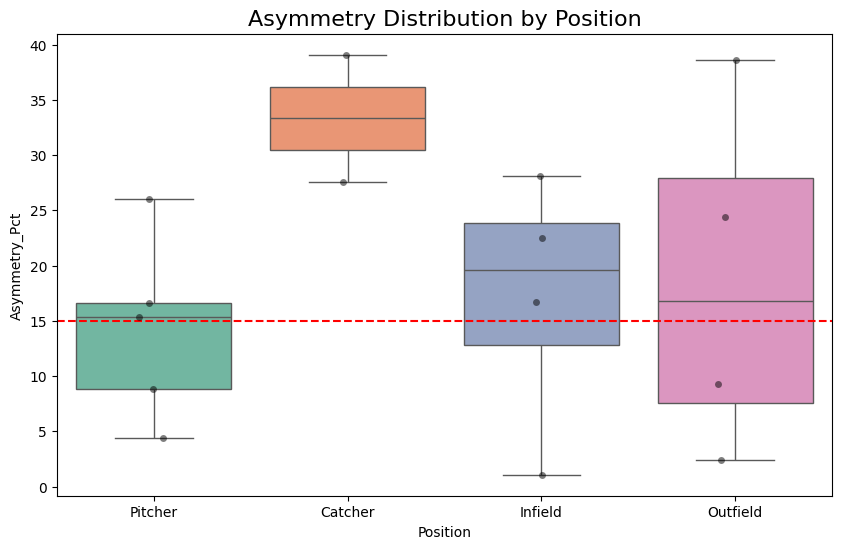

In [6]:
plt.figure(figsize=(10, 6))
# Create a box plot to see the 'spread' of risk by position
sns.boxplot(data=baseball_stats, x='Position', y='Asymmetry_Pct', palette='Set2')

# Add individual player dots on top so we see the outliers
sns.stripplot(data=baseball_stats, x='Position', y='Asymmetry_Pct', color='black', alpha=0.5)

plt.title('Asymmetry Distribution by Position', fontsize=16)
plt.axhline(15, color='red', linestyle='--')
plt.show()

In [7]:
# 1. Filter for the "Red Flag" players (Asymmetry > 15%)
# We sort by the highest risk so the most lopsided players are at the top
priority_list = baseball_stats[baseball_stats['Asymmetry_Pct'] > 15].sort_values(by='Asymmetry_Pct', ascending=False)

# 2. Clean up the columns for the coaches (keep it simple)
report_columns = ['Player_Name', 'Position', 'Asymmetry_Pct', 'NordBord_L_Torque', 'NordBord_R_Torque']
final_report = priority_list[report_columns]

# 3. Export to an Excel file
final_report.to_excel('Priority_Injury_Prevention_List.xlsx', index=False)

print(f"✅ SUCCESS: Report generated for {len(final_report)} priority athletes.")
print("Check your sidebar folder to download 'Priority_Injury_Prevention_List.xlsx'.")

✅ SUCCESS: Report generated for 10 priority athletes.
Check your sidebar folder to download 'Priority_Injury_Prevention_List.xlsx'.


In [8]:
# 1. Filter for athletes with asymmetry UNDER 15%
# We'll call this the 'Ready List'
ready_list = baseball_stats[baseball_stats['Asymmetry_Pct'] <= 15].sort_values(by='Asymmetry_Pct')

# 2. Display the 'Clean' results
print(f"--- ✅ ATHLETE READINESS REPORT: SAFE ZONE (<=15%) ---")
if not ready_list.empty:
    # We show their name, position, and their specific asymmetry score
    print(ready_list[['Player_Name', 'Position', 'Asymmetry_Pct']].round(1))
    print(f"\nTotal Athletes Ready: {len(ready_list)}")
else:
    print("Zero athletes currently meet the 15% symmetry threshold.")

--- ✅ ATHLETE READINESS REPORT: SAFE ZONE (<=15%) ---
      Player_Name  Position  Asymmetry_Pct
10  Nate Robinson   Infield            1.1
6     Jordan Bell  Outfield            2.4
12   Blake Murphy   Pitcher            4.4
0   Jack Thompson   Pitcher            8.8
11    Alex Foster  Outfield            9.3

Total Athletes Ready: 5


In [9]:
# --- THE HIGH-PERFORMANCE DASHBOARD SUMMARY ---

total_athletes = len(baseball_stats)
at_risk = len(priority_list)
ready = len(ready_list)
risk_pct = (at_risk / total_athletes) * 100

print("=========================================")
print("📊 TEAM PERFORMANCE & READINESS SUMMARY")
print("=========================================")
print(f"Total Athletes Tested: {total_athletes}")
print(f"🟢 Ready to Train:      {ready} ({ (ready/total_athletes)*100:.1f}%)")
print(f"🔴 Priority Intervention: {at_risk} ({risk_pct:.1f}%)")
print("-----------------------------------------")
print(f"Average Team Asymmetry: {baseball_stats['Asymmetry_Pct'].mean():.1f}%")
print(f"Team Peak Power Avg:    {baseball_stats['Peak_Power_Wkg'].mean():.1f} W/kg")
print("=========================================")

if risk_pct > 30:
    print("⚠️ ALERT: High systemic asymmetry detected. Recommend group-wide recovery protocol.")
else:
    print("✅ STATUS: Team showing acceptable mechanical symmetry.")

📊 TEAM PERFORMANCE & READINESS SUMMARY
Total Athletes Tested: 15
🟢 Ready to Train:      5 (33.3%)
🔴 Priority Intervention: 10 (66.7%)
-----------------------------------------
Average Team Asymmetry: 18.7%
Team Peak Power Avg:    56.3 W/kg
⚠️ ALERT: High systemic asymmetry detected. Recommend group-wide recovery protocol.
